# Import Libraries and Load Dataset

In [ ]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import nltk
import string
import re
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Download stopwords from nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Loading the dataset normally to inspect it
df = pd.read_csv("spam.csv", encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Keep only the necessary columns
df = df[['v1', 'v2']]  # Retain only the first two columns

In [ ]:
# Rename the columns to 'label' and 'message'
df.columns = ['label', 'message']

In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Distribution of Labels
label_distribution = df['label'].value_counts().reset_index()
label_distribution.columns = ['Label', 'Count']

# Summary statistics
summary_stats = {
    'Total Messages': len(df),
    'Unique Messages': df['message'].nunique(),
    'Unique Labels': df['label'].nunique(),
}

print("Label Distribution:\n", label_distribution)
print("Summary Statistics:\n", summary_stats)

Label Distribution:
   Label  Count
0   ham   4825
1  spam    747
Summary Statistics:
 {'Total Messages': 5572, 'Unique Messages': 5169, 'Unique Labels': 2}


In [ ]:
# Example for generating Topic and Token distribution
token_counts = df['message'].str.split().str.len()
total_tokens = token_counts.sum()
unique_terms = df['message'].str.split().explode().nunique()

topic_distribution = {
    'Topic': 'SMS',
    'Tokens': total_tokens,
    'Unique Terms': unique_terms
}

print("Topic Distribution:\n", topic_distribution)


Topic Distribution:
 {'Topic': 'SMS', 'Tokens': 86335, 'Unique Terms': 15585}


# Data Preprocessing

In [ ]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to clean the text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters and punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove leading and trailing whitespaces
    text = text.strip()

    # Remove stopwords and apply lemmatization
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stopwords.words('english')])

    return text

# Apply the cleaning function to the dataset
df['cleaned_message'] = df['message'].apply(preprocess_text)

# Display the first few rows to verify
df.head()

,label,message,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


### Visualizing the Most Frequent Words

<ipython-input-9-cb021081e4f1>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.head(10).values, y=word_counts.head(10).index, palette='viridis')


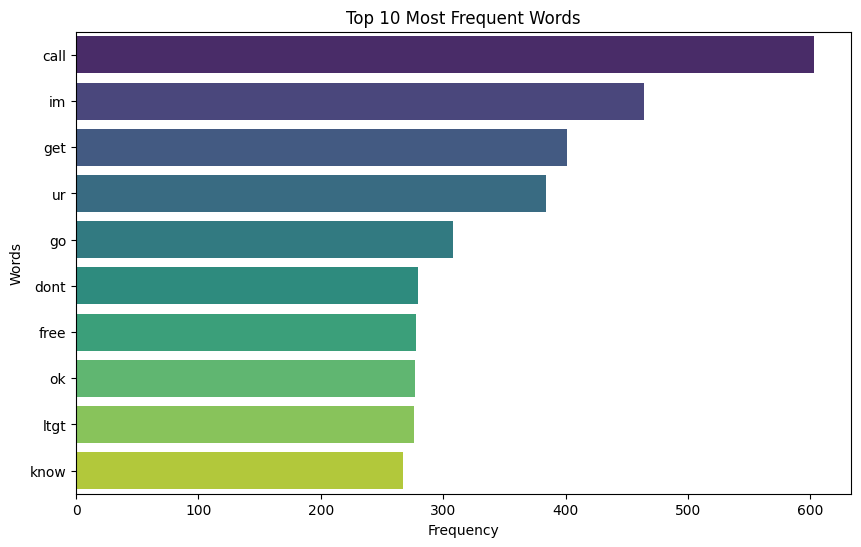

In [ ]:
# Create a CountVectorizer instance to count word occurrences
count_vectorizer = CountVectorizer()

# Fit and transform the cleaned messages
word_count_matrix = count_vectorizer.fit_transform(df['cleaned_message'])

# Convert to a DataFrame
word_count_df = pd.DataFrame(word_count_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

# Calculate the total occurrences of each word
word_counts = word_count_df.sum().sort_values(ascending=False)

# Visualization of Top 10 Most Frequent Words
plt.figure(figsize=(10, 6))
sns.barplot(x=word_counts.head(10).values, y=word_counts.head(10).index, palette='viridis')
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

### Finding Unique Words

In [ ]:
# Unique words
unique_words = set(" ".join(df['cleaned_message']).split())
print(f"Total Unique Words: {len(unique_words)}")

Total Unique Words: 7896


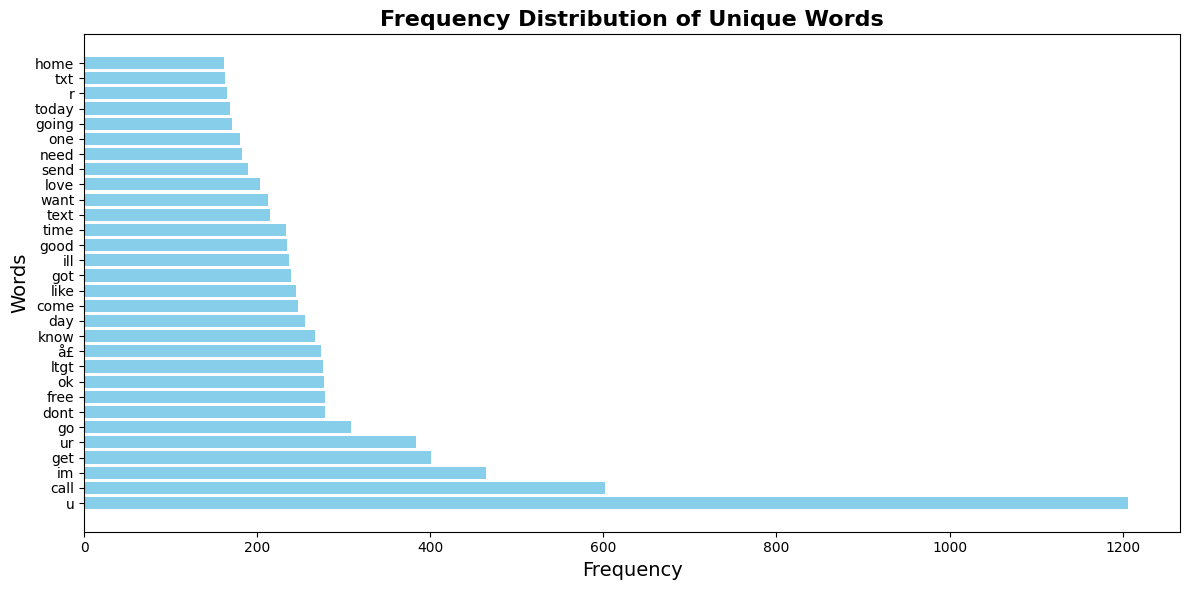

In [ ]:
import matplotlib.pyplot as plt
from nltk import FreqDist

# Get all words from cleaned messages
all_words = ' '.join(df['cleaned_message']).split()
freq_dist = FreqDist(all_words)

# Get the 30 most common words and their frequencies
common_words = freq_dist.most_common(30)
words, frequencies = zip(*common_words)

# Create a horizontal bar plot
plt.figure(figsize=(12, 6))
plt.barh(words, frequencies, color='skyblue')

# Set titles and labels
plt.title('Frequency Distribution of Unique Words', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Words', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()



In [ ]:
preprocessed_token_counts = df['cleaned_message'].str.split().str.len()  # Counts the number of tokens in each preprocessed message
total_preprocessed_tokens = preprocessed_token_counts.sum()
unique_preprocessed_terms = df['cleaned_message'].str.split().explode().nunique()

### Finding N-Grams

In [ ]:
# Bigrams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
bigram_count_matrix = bigram_vectorizer.fit_transform(df['cleaned_message'])
bigram_counts = bigram_count_matrix.sum(axis=0).A1
bigram_df = pd.DataFrame(bigram_counts, index=bigram_vectorizer.get_feature_names_out(), columns=['count'])
top_bigrams = bigram_df.sort_values(by='count', ascending=False)


# Trigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))
trigram_count_matrix = trigram_vectorizer.fit_transform(df['cleaned_message'])
trigram_counts = trigram_count_matrix.sum(axis=0).A1
trigram_df = pd.DataFrame(trigram_counts, index=trigram_vectorizer.get_feature_names_out(), columns=['count'])
top_trigrams = trigram_df.sort_values(by='count', ascending=False)




### Display Top 10 Bigrams

<ipython-input-13-5636b88ca09a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bigrams.head(10)['count'].values, y=top_bigrams.head(10).index, palette='viridis')


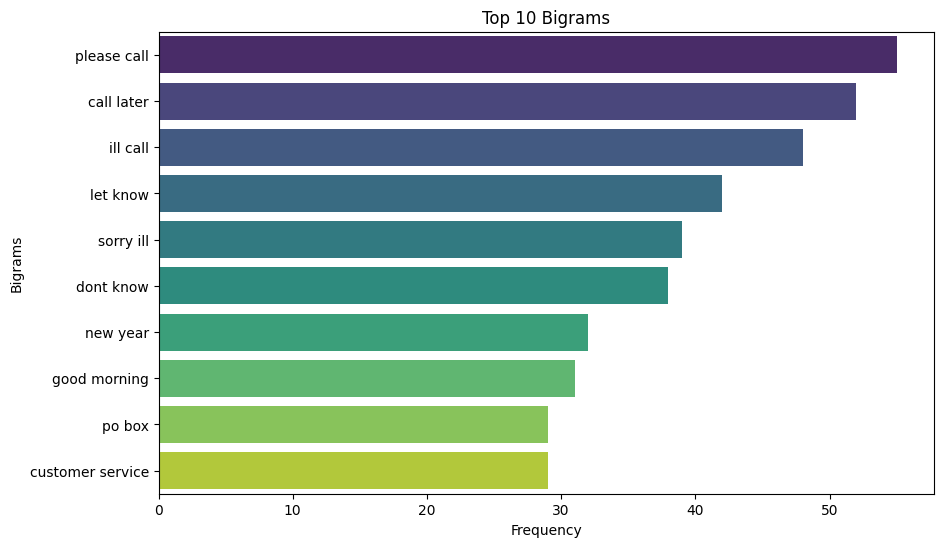

In [ ]:
# Visualization of Top 10 Bigrams
plt.figure(figsize=(10, 6))
sns.barplot(x=top_bigrams.head(10)['count'].values, y=top_bigrams.head(10).index, palette='viridis')
plt.title('Top 10 Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()



### Display Top 10 Tigrams

<ipython-input-14-e7de27a3f71a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_trigrams.head(10)['count'].values, y=top_trigrams.head(10).index, palette='viridis')


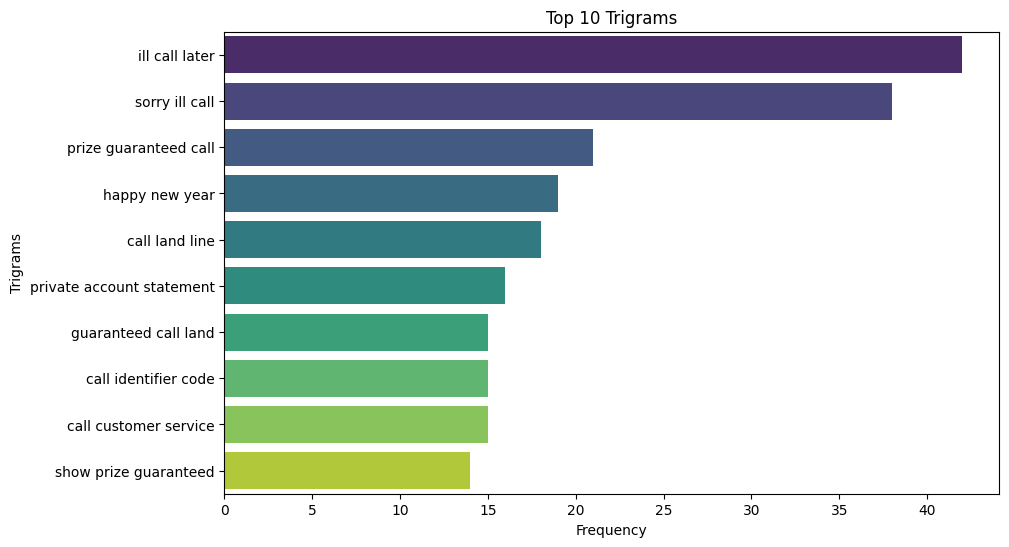

In [ ]:
# Visualization of Top 10 Trigrams
plt.figure(figsize=(10, 6))
sns.barplot(x=top_trigrams.head(10)['count'].values, y=top_trigrams.head(10).index, palette='viridis')
plt.title('Top 10 Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigrams')
plt.show()

# Splitting the Dataset

In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})  # Encode labels
X = df['cleaned_message']
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')


Training set size: 4457
Test set size: 1115


## Feature Extraction (TF-IDF Vectorization)

In [ ]:
# Convert text to numerical data using TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Visualizing Message Length Distribution

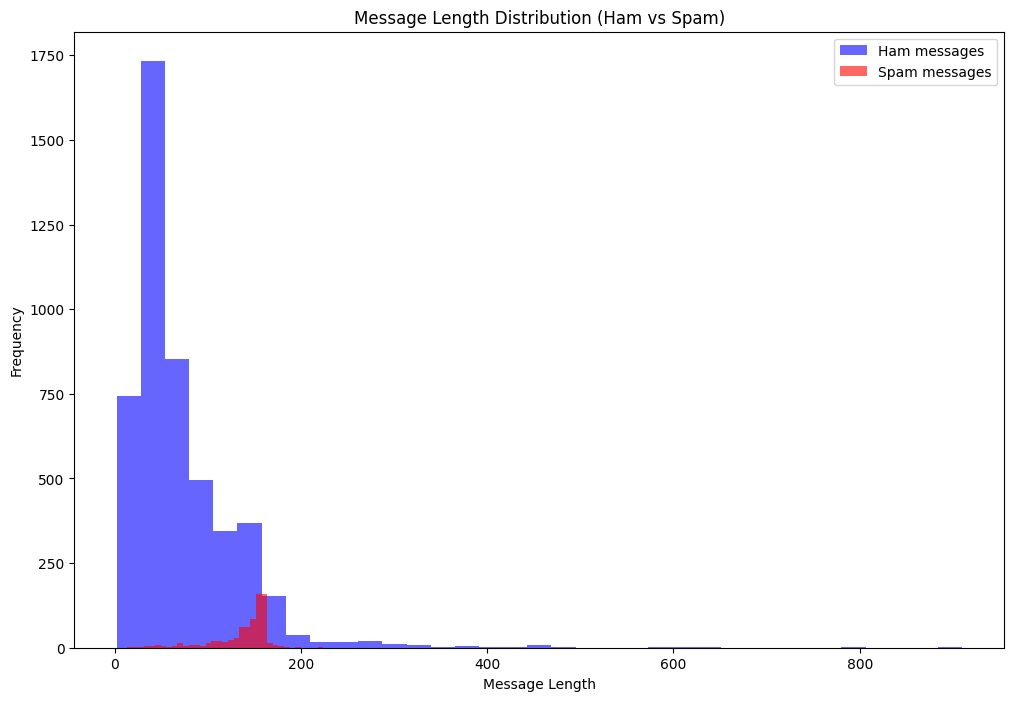

In [ ]:
import matplotlib.pyplot as plt
# Add a new column to capture message lengths
df['message_len'] = df['message'].apply(len)

# Create a figure
plt.figure(figsize=(12, 8))

# Plot ham messages
df[df['label'] == 0]['message_len'].plot(kind='hist', bins=35, color='blue', alpha=0.6, label='Ham messages')

# Plot spam messages
df[df['label'] == 1]['message_len'].plot(kind='hist', bins=35, color='red', alpha=0.6, label='Spam messages')

# Add labels and title
plt.legend()
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Message Length Distribution (Ham vs Spam)")
plt.show()


# Model Building and Training

## Logistic *Regression*

In [ ]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Logistic Regression
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear']}
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_tfidf, y_train)  # Use X_train_tfidf

# Best model and evaluation
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_tfidf)  # Use X_test_tfidf

# Print metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr) * 100
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}%")
print(classification_report(y_test, y_pred_lr))



Logistic Regression Accuracy: 97.76%
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.87      0.91       150

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Hyperparameter grid for Naive Bayes
param_grid_nb = {'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]}
grid_nb = GridSearchCV(MultinomialNB(), param_grid_nb, cv=5, scoring='f1')
grid_nb.fit(X_train_tfidf, y_train)

# Best model and evaluation
best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test_tfidf)

# Print metrics for Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb) * 100
print(f"Naive Bayes Accuracy: {accuracy_nb:.2f}%")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 97.85%
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.86      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## Support Vector Machine

In [ ]:
from sklearn.svm import SVC

# Hyperparameter grid for SVM
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='f1')
grid_svm.fit(X_train_tfidf, y_train)

# Best model and evaluation
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_tfidf)

# Print metrics for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm) * 100
print(f"Support Vector Machine Accuracy: {accuracy_svm:.2f}%")
print(classification_report(y_test, y_pred_svm))


Support Vector Machine Accuracy: 98.03%
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter grid for Random Forest
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train_tfidf, y_train)

# Best model and evaluation
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_tfidf)

# Print metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"Random Forest Accuracy: {accuracy_rf:.2f}%")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 97.67%
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## XGBoost

In [ ]:
# Initialize the XGBoost model
xgb_clf = xgb.XGBClassifier(verbosity=0)

# Hyperparameter tuning using RandomizedSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Set up the RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_grid_xgb,
    n_iter=10,
    cv=3,
    random_state=42,
    scoring='accuracy'
)

# Fit the model with the randomized search
random_search_xgb.fit(X_train_tfidf, y_train)

# Get the best hyperparameters
best_params = random_search_xgb.best_params_
print("Best parameters for XGBoost:")
for param, value in best_params.items():
    print(f'{param}: {value}')

# Predict using the best model
y_pred_best_xgb = random_search_xgb.best_estimator_.predict(X_test_tfidf)

# Evaluate the model with the best parameters
accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb) * 100
print(f'Accuracy (with best parameters for XGBoost): {accuracy_best_xgb:.2f}%')
print(classification_report(y_test, y_pred_best_xgb))


Best parameters for XGBoost:
subsample: 1.0
n_estimators: 300
max_depth: 6
learning_rate: 0.1
colsample_bytree: 0.8
Accuracy (with best parameters for XGBoost): 97.04%
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       0.98      0.80      0.88       150

    accuracy                           0.97      1115
   macro avg       0.97      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



# Testing and Evaluation

In [ ]:
# Initialize a list to collect results
results = []

# Logistic Regression
y_pred_lr = best_lr.predict(X_test_tfidf)
results.append({
    'Model': 'Logistic Regression',
    'Accuracy (%)': accuracy_score(y_test, y_pred_lr) * 100,
    'Precision (%)': precision_score(y_test, y_pred_lr) * 100,
    'Recall (%)': recall_score(y_test, y_pred_lr) * 100,
    'F1 Score (%)': f1_score(y_test, y_pred_lr) * 100,
    'Classification Report': classification_report(y_test, y_pred_lr, output_dict=True)
})

# Naive Bayes
y_pred_nb = best_nb.predict(X_test_tfidf)
results.append({
    'Model': 'Naive Bayes',
    'Accuracy (%)': accuracy_score(y_test, y_pred_nb) * 100,
    'Precision (%)': precision_score(y_test, y_pred_nb) * 100,
    'Recall (%)': recall_score(y_test, y_pred_nb) * 100,
    'F1 Score (%)': f1_score(y_test, y_pred_nb) * 100,
    'Classification Report': classification_report(y_test, y_pred_nb, output_dict=True)
})

# Support Vector Machine
y_pred_svm = best_svm.predict(X_test_tfidf)
results.append({
    'Model': 'Support Vector Machine',
    'Accuracy (%)': accuracy_score(y_test, y_pred_svm) * 100,
    'Precision (%)': precision_score(y_test, y_pred_svm) * 100,
    'Recall (%)': recall_score(y_test, y_pred_svm) * 100,
    'F1 Score (%)': f1_score(y_test, y_pred_svm) * 100,
    'Classification Report': classification_report(y_test, y_pred_svm, output_dict=True)
})

# Random Forest
y_pred_rf = best_rf.predict(X_test_tfidf)
results.append({
    'Model': 'Random Forest',
    'Accuracy (%)': accuracy_score(y_test, y_pred_rf) * 100,
    'Precision (%)': precision_score(y_test, y_pred_rf) * 100,
    'Recall (%)': recall_score(y_test, y_pred_rf) * 100,
    'F1 Score (%)': f1_score(y_test, y_pred_rf) * 100,
    'Classification Report': classification_report(y_test, y_pred_rf, output_dict=True)
})

# XGBoost
y_pred_xgb = random_search_xgb.best_estimator_.predict(X_test_tfidf)
results.append({
    'Model': 'XGBoost',
    'Accuracy (%)': accuracy_score(y_test, y_pred_xgb) * 100,
    'Precision (%)': precision_score(y_test, y_pred_xgb) * 100,
    'Recall (%)': recall_score(y_test, y_pred_xgb) * 100,
    'F1 Score (%)': f1_score(y_test, y_pred_xgb) * 100,
    'Classification Report': classification_report(y_test, y_pred_xgb, output_dict=True)
})

# Step 2: Create DataFrame
results_df = pd.DataFrame(results)

# Step 3: Display the results
print("\nOverall Performance Metrics:\n")
results_df[['Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']]



Overall Performance Metrics:



,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,97.757848,96.296296,86.666667,91.228070
1,Naive Bayes,97.847534,97.727273,86.000000,91.489362
2,Support Vector Machine,98.026906,99.230769,86.000000,92.142857
3,Random Forest,97.668161,100.000000,82.666667,90.510949
4,XGBoost,97.040359,97.560976,80.000000,87.912088


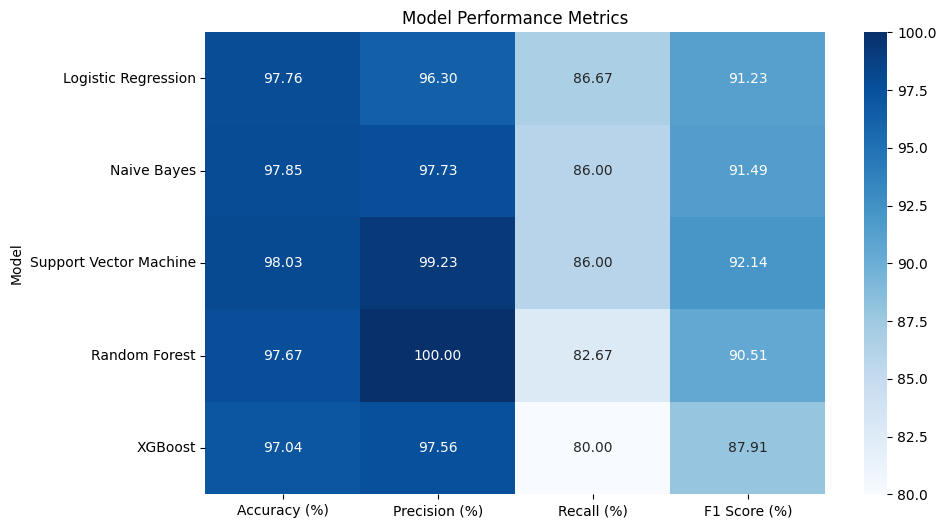

In [ ]:
# Create a heatmap of the overall performance metrics
results_df.set_index('Model', inplace=True)
plt.figure(figsize=(10, 6))
sns.heatmap(results_df[['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']], annot=True, cmap='Blues', fmt='.2f')
plt.title('Model Performance Metrics')
plt.show()


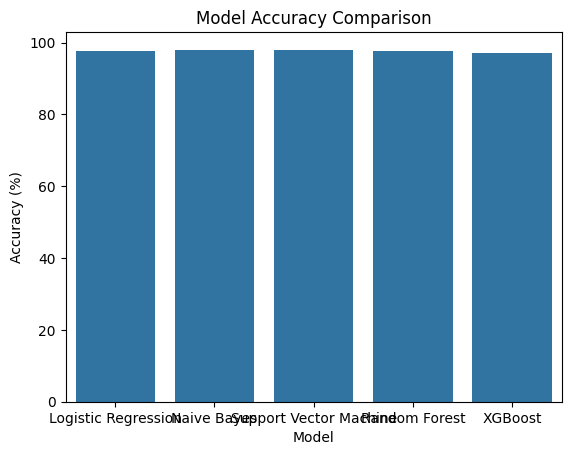

In [ ]:
import seaborn as sns

sns.barplot(x='Model', y='Accuracy (%)', data=results_df)
plt.title('Model Accuracy Comparison')
plt.show()

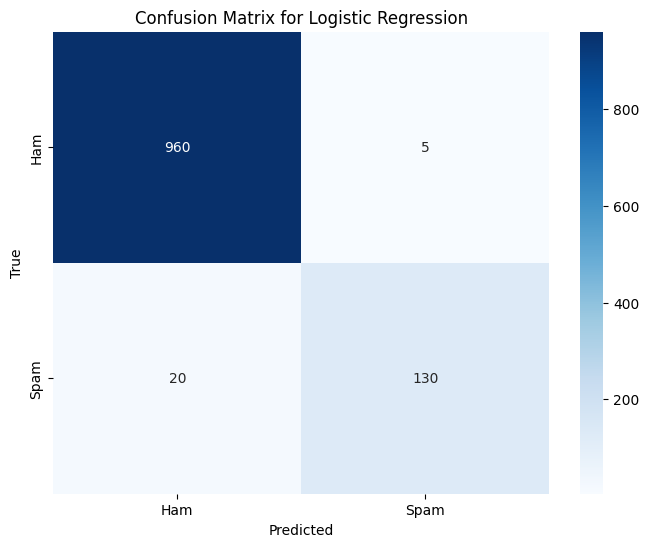

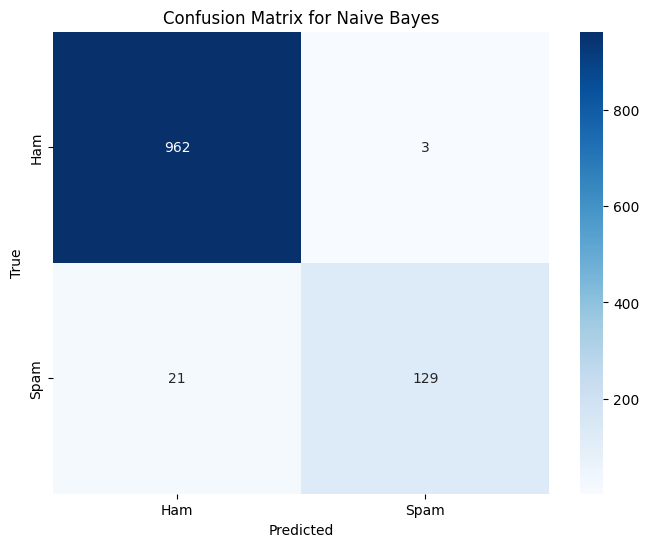

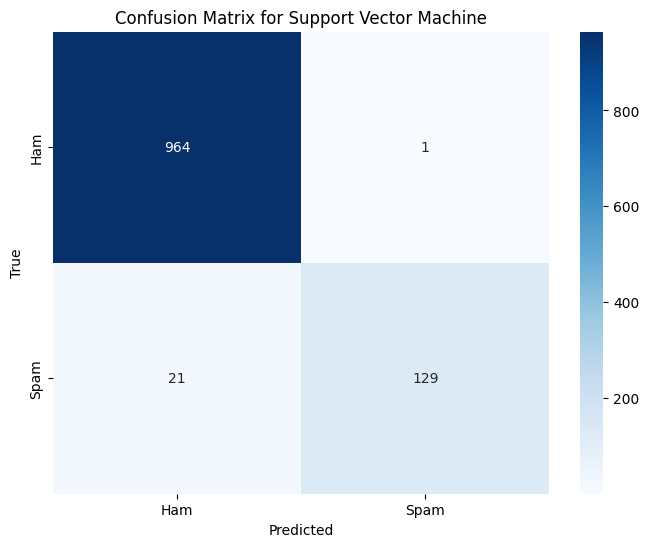

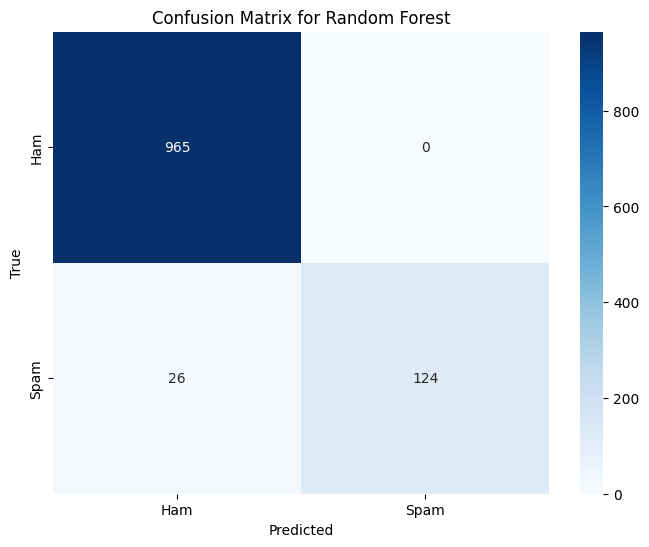

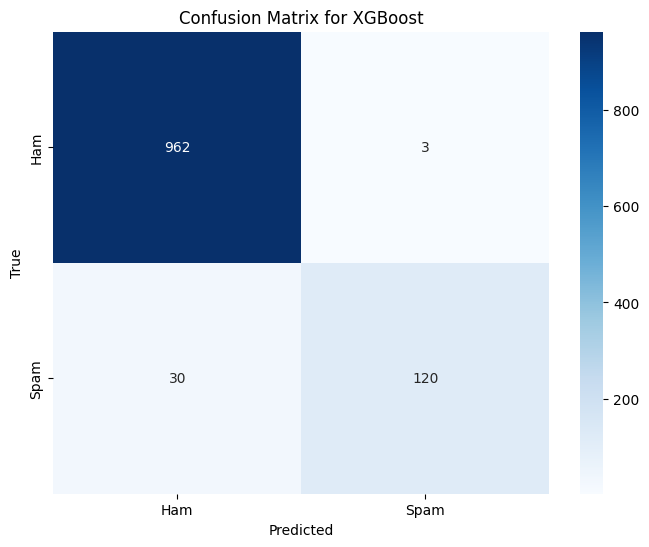

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

# Plot confusion matrices for each model
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')
plot_confusion_matrix(y_test, y_pred_nb, 'Naive Bayes')
plot_confusion_matrix(y_test, y_pred_svm, 'Support Vector Machine')
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')


## ROC

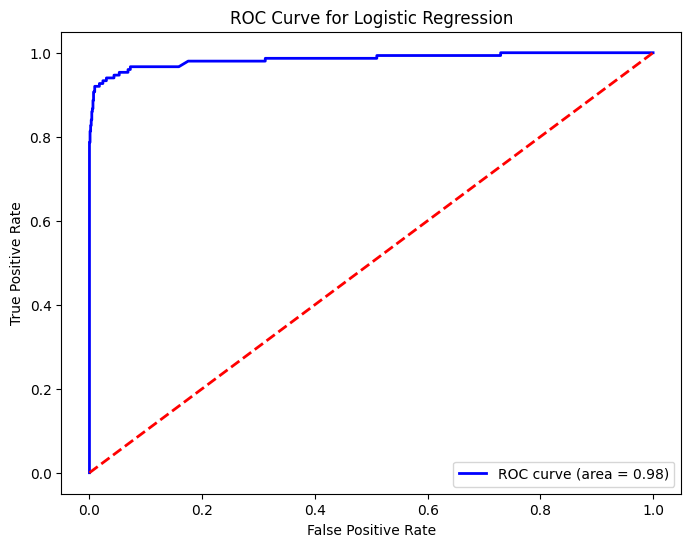

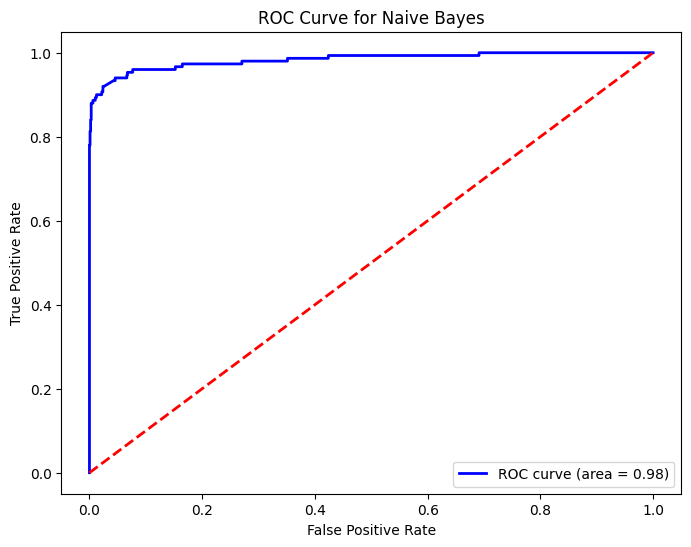

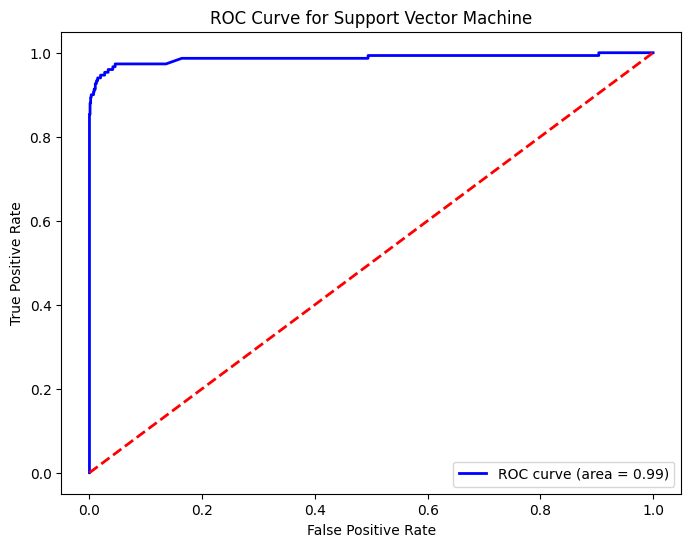

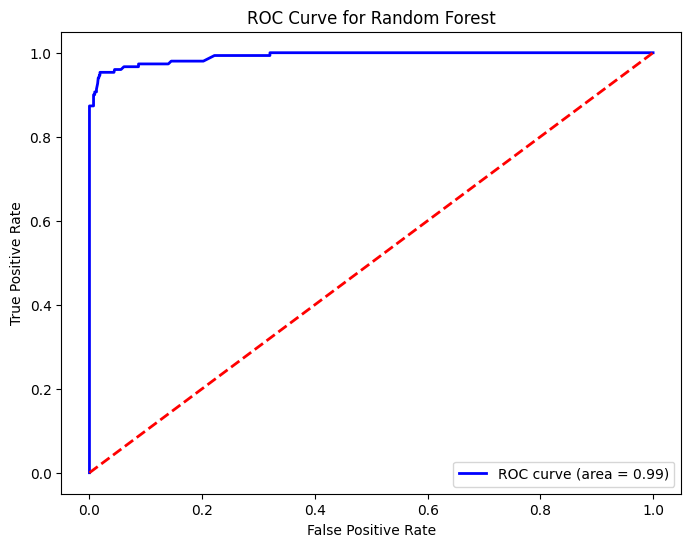

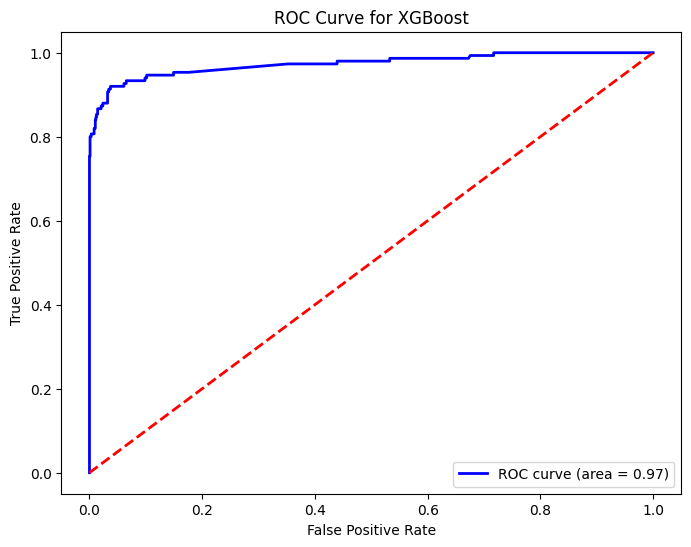

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_scores, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()

# Get predicted probabilities for the positive class
y_scores_lr = best_lr.predict_proba(X_test_tfidf)[:, 1]
y_scores_nb = best_nb.predict_proba(X_test_tfidf)[:, 1]
y_scores_svm = best_svm.decision_function(X_test_tfidf)
y_scores_rf = best_rf.predict_proba(X_test_tfidf)[:, 1]
y_scores_xgb = random_search_xgb.best_estimator_.predict_proba(X_test_tfidf)[:, 1]

# Plot ROC curves
plot_roc_curve(y_test, y_scores_lr, 'Logistic Regression')
plot_roc_curve(y_test, y_scores_nb, 'Naive Bayes')
plot_roc_curve(y_test, y_scores_svm, 'Support Vector Machine')
plot_roc_curve(y_test, y_scores_rf, 'Random Forest')
plot_roc_curve(y_test, y_scores_xgb, 'XGBoost')



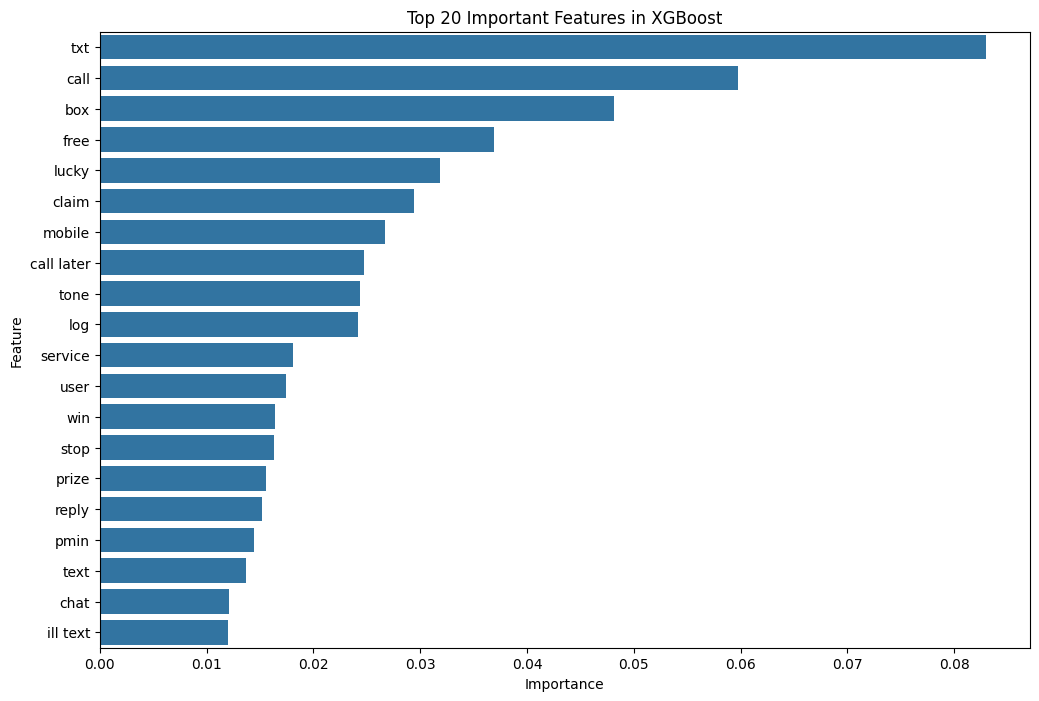

In [ ]:
# Get feature importances from the best XGBoost model
feature_importances = random_search_xgb.best_estimator_.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 20 Important Features in XGBoost')
plt.show()
